In [6]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter

In [7]:
# Implement baseline algorithm

def baseline_max_sublist(arr):
    max_sum = float('-inf')
    for start in range(len(arr)):
        current_sum = 0
        for end in range(start, len(arr)):
            current_sum += arr[end]
            if current_sum > max_sum:
                max_sum = current_sum
    return max_sum

In [8]:
# Implement target algorithm

def kadane_max_sublist(arr):
    max_so_far = float('-inf')
    current_max = 0
    for i in range(len(arr)):
        current_max += arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far

test = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
print(baseline_max_sublist(test), kadane_max_sublist(test))  # both should print 6

6 6


In [9]:


def random_list(length, lower_bound=-100, upper_bound=100):
    return numpy.random.randint(lower_bound, upper_bound + 1, size=length)

lengths = [100, 500, 1000, 2500, 5000, 10000]
trials = 5
baseline_times = []
kadane_times = []

for n in lengths:
    b_total = 0
    k_total = 0
    for _ in range(trials):
        data = random_list(n)

        start = perf_counter()
        baseline_max_sublist(data)
        b_total += perf_counter() - start

        start = perf_counter()
        kadane_max_sublist(data)
        k_total += perf_counter() - start

    baseline_times.append(b_total / trials)
    kadane_times.append(k_total / trials)

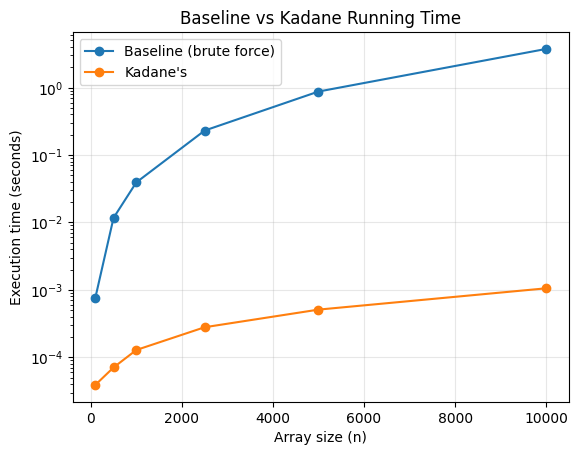

In [10]:
plt.plot(lengths, baseline_times, marker='o', label='Baseline (brute force)')
plt.plot(lengths, kadane_times, marker='o', label="Kadane's")
plt.yscale('log')
plt.xlabel('Array size (n)')
plt.ylabel('Execution time (seconds)')
plt.title('Baseline vs Kadane Running Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
for n, b, k in zip(lengths, baseline_times, kadane_times):
    print(f"n={n:>6}  baseline={b:.6f} s  kadane={k:.6f} s")

n=   100  baseline=0.000759 s  kadane=0.000039 s
n=   500  baseline=0.011672 s  kadane=0.000071 s
n=  1000  baseline=0.039235 s  kadane=0.000128 s
n=  2500  baseline=0.230279 s  kadane=0.000279 s
n=  5000  baseline=0.873572 s  kadane=0.000509 s
n= 10000  baseline=3.743256 s  kadane=0.001054 s
